# Function Approximation with the `MultiDense` Custom Keras Layer

This notebook demonstrates the use of a custom Keras layer — **`MultiDense`** — for **1-D function approximation via supervised regression**.

We will:
1. Define and register the `MultiDense` layer.
2. Generate a synthetic dataset from a known mathematical function.
3. Build two models: a **baseline MLP** and a **MultiDense model**.
4. Train both models with full reproducibility guarantees.
5. Compare their performance and visualise results.

---

## What is `MultiDense`?

A standard `Dense` layer applies a **single activation function** to all of its output neurons.  
`MultiDense` generalises this by allowing you to split the output neurons into **partitions**, each with its own activation:

$$A = \text{concat}\bigl(\phi_1(Z_{:,\,:n_1}),\;\phi_2(Z_{:,\,n_1:n_1+n_2}),\;\ldots\bigr)$$

where $Z = XW + b$ is computed **once** with a single weight matrix.

This is useful when:
- Different neurons benefit from different inductive biases (e.g. monotone vs. oscillatory subspaces).
- You want some neurons to saturate (sigmoid/tanh) and others to stay unbounded (relu/linear).
- You are experimenting with heterogeneous activation mixtures as a form of architectural regularisation.

## 0 · Setup & Reproducibility

We fix **every** source of randomness before importing any other library.  
`tf.config.experimental.enable_op_determinism()` forces TensorFlow to use only deterministic GPU/CPU kernels — at a small runtime cost.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Input, Layer
from tensorflow.keras.models import Model, Sequential


In [2]:
RANDOM_SEED = 42

os.environ["PYTHONHASHSEED"] = f"{RANDOM_SEED}"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

tf.keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

print(f"TensorFlow version : {tf.__version__}")
print(f"Random seed        : {RANDOM_SEED}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
Random seed        : 42
GPUs available     : []


In [3]:
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 1 · The `MultiDense` Layer


In [4]:
class MultiDense(Layer):
    def __init__(self, units, activations, **kwargs):
        super().__init__(**kwargs)

        units = units if isinstance(units, list) else [units]
        activations = activations if isinstance(activations, list) else [activations]

        if len(units) != len(activations):
            raise ValueError(
                f"units and activations must match: {len(units)} vs {len(activations)}"
            )

        self.units = units
        self.activations = [tf.keras.activations.get(a) for a in activations]

    def build(self, input_shape):
        total_units = sum(self.units)

        self.kernel = self.add_weight(
            shape=(input_shape[-1], total_units),
            name="kernel",
            initializer="glorot_uniform",
            trainable=True,
        )

        self.bias = self.add_weight(
            shape=(total_units,),
            name="bias",
            initializer="zeros",
            trainable=True,
        )

        super().build(input_shape)

    def call(self, inputs):
        z = tf.matmul(inputs, self.kernel)
        z = tf.add(z, self.bias)

        z_splits = tf.split(z, self.units, axis=-1)
        a_splits = [act(zb) for act, zb in zip(self.activations, z_splits)]

        a = tf.concat(a_splits, axis=-1)
        return a


## 2 · Dataset Generation

We approximate the function

$$f(x) = x \cdot \sin(x)$$

on $x \in [-3\pi,\; 3\pi]$. This function is interesting because it combines:

- **Oscillatory behaviour** (sin) — requires tanh / sine-like representations.
- **Growing amplitude** (×x) — benefits from unbounded activations (relu / linear).

This mixture makes it a good stress-test for `MultiDense`, whose heterogeneous activations can simultaneously model both aspects.

The dataset is split **70 / 15 / 15** into train, validation and test sets.

In [5]:
N_SAMPLES = 2_000
X_MIN, X_MAX = -3 * np.pi, 3 * np.pi


def target_fn(x: np.ndarray) -> np.ndarray:
    return x * np.sin(x)


rng = np.random.default_rng(RANDOM_SEED)
x_all = rng.uniform(X_MIN, X_MAX, size=(N_SAMPLES, 1)).astype(np.float32)
y_all = target_fn(x_all).astype(np.float32)

x_train, x_tmp, y_train, y_tmp = train_test_split(
    x_all,
    y_all,
    test_size=0.30,
    random_state=RANDOM_SEED,
)
x_val, x_test, y_val, y_test = train_test_split(
    x_tmp,
    y_tmp,
    test_size=0.50,
    random_state=RANDOM_SEED,
)

print(f"Train : {len(x_train):>5} samples")
print(f"Val   : {len(x_val):>5} samples")
print(f"Test  : {len(x_test):>5} samples")

x_plot = np.linspace(X_MIN, X_MAX, 1_000, dtype=np.float32).reshape(-1, 1)
y_plot = target_fn(x_plot)

Train :  1400 samples
Val   :   300 samples
Test  :   300 samples


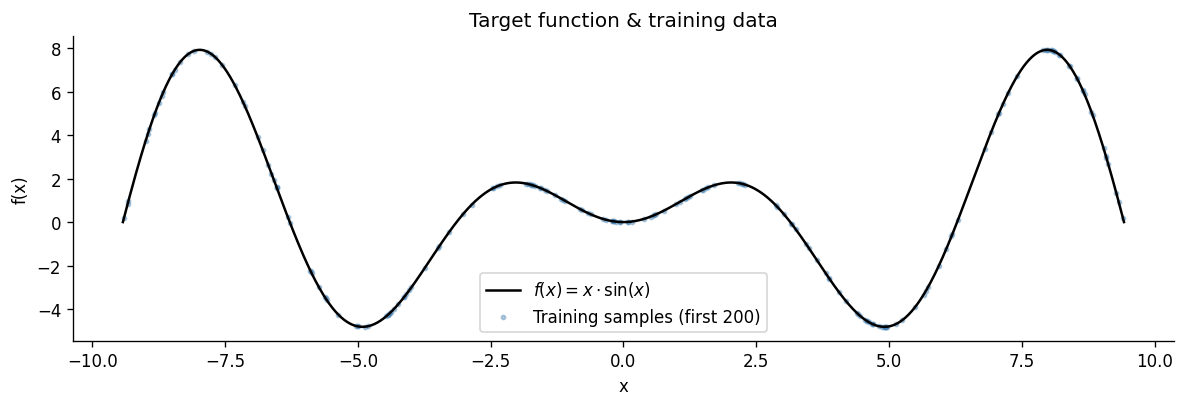

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(x_plot, y_plot, "k-", lw=1.5, label="$f(x) = x\\cdot\\sin(x)$")
ax.scatter(
    x_train[:200],
    y_train[:200],
    s=6,
    alpha=0.4,
    color="steelblue",
    label="Training samples (first 200)",
)
ax.set(xlabel="x", ylabel="f(x)", title="Target function & training data")
ax.legend()
plt.tight_layout()
plt.show()

## 3 · Model Architectures

Both models are **mathematically and numerically identical** by construction.

`MultiDense(units=[N], activations=["act"])` with a single partition reduces exactly to
`Dense(N, activation="act")`:

- The weight matrix shape is `(n_in, N)` in both cases.
- `tf.split` with one chunk is a no-op that returns the full tensor.
- One activation is applied to the full tensor.
- `tf.concat` of one tensor is a no-op.

The purpose of this experiment is therefore **not** to compare performance, but to
**verify that `MultiDense` is a correct drop-in replacement for `Dense`**: if the
implementation is correct, both models must converge to the same R² when given
identical weights and training conditions.

To make the comparison airtight we:
1. Use **identical architecture** (same units, same activation, same depth).
2. **Copy weights** from the baseline into the MultiDense model after initialisation,
   so both models start from exactly the same point in parameter space.
3. **Reset the global seed** to the same value before each `.fit()` call, so every
   stochastic training step (batch shuffle, etc.) is identical.

| Layer | Baseline (`Dense`) | MultiDense equivalent |
|-------|--------------------|-----------------------|
| 1 | `Dense(64, tanh)` | `MultiDense([64], ["tanh"])` |
| 2 | `Dense(64, tanh)` | `MultiDense([64], ["tanh"])` |
| 3 | `Dense(32, tanh)` | `MultiDense([32], ["tanh"])` |
| out | `Dense(1, linear)` | `Dense(1, linear)` |


In [7]:
def build_baseline(seed=RANDOM_SEED) -> Model:
    tf.keras.utils.set_random_seed(seed)
    return tf.keras.Sequential(
        [
            Input(shape=(1,)),
            Dense(units=64, activation="tanh"),
            Dense(units=64, activation="tanh"),
            Dense(units=32, activation="tanh"),
            Dense(units=1, activation="linear"),
        ],
    )


baseline_model = build_baseline()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
def build_multidense_model(seed=RANDOM_SEED) -> Model:
    tf.keras.utils.set_random_seed(seed)
    return Sequential(
        [
            Input(shape=(1,)),
            MultiDense(units=64, activations="tanh"),
            MultiDense(units=64, activations="tanh"),
            MultiDense(units=32, activations="tanh"),
            MultiDense(units=1, activations="linear"),
        ],
    )


multidense_model = build_multidense_model()
multidense_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ multi_dense (MultiDense)        │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_dense_1 (MultiDense)      │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_dense_2 (MultiDense)      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_dense_3 (MultiDense)      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4 · Training

We use a custom `BatchLogger` callback to record the **MSE loss at every N batches**,
giving us fine-grained training dynamics in addition to the standard per-epoch curves.

Both models are compiled with:
- **Optimiser**: Adam (lr = 1e-3)
- **Loss**: MSE
- **Metric**: MAE

Crucially, the global seed is **reset to `RANDOM_SEED` before each `.fit()` call**
inside `compile_and_train`. This ensures the batch-shuffle order is identical for
both models, so any difference in training trajectory is attributable solely to the
layer implementation, not to data ordering.


In [9]:
LOG_EVERY_N_BATCHES = 10


class BatchLogger(tf.keras.callbacks.Callback):
    """Records MSE loss every `log_every` batches for intra-epoch visualisation."""

    def __init__(self, log_every: int = LOG_EVERY_N_BATCHES):
        super().__init__()
        self.log_every = log_every
        self.batch_loss: list[float] = []
        self.batch_steps: list[int] = []
        self._global_step = 0

    def on_train_batch_end(self, batch, logs=None):
        self._global_step += 1
        if self._global_step % self.log_every == 0:
            self.batch_loss.append(logs.get("loss", float("nan")))
            self.batch_steps.append(self._global_step)

In [10]:
EPOCHS = 300
BATCH_SIZE = 64


def compile_and_train(model, name=""):
    tf.keras.utils.set_random_seed(RANDOM_SEED)
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )

    logger = BatchLogger(log_every=LOG_EVERY_N_BATCHES)
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True,
        verbose=0,
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, logger],
        verbose=0,
    )

    return history, logger


In [11]:
hist_base, logger_base = compile_and_train(baseline_model, "Baseline MLP")

In [12]:
hist_multi, logger_multi = compile_and_train(multidense_model, "MultiDense Model")

## 5 · Evaluation

We report **R²** (coefficient of determination) on the held-out test set as our primary scalar metric.  
R² = 1 means perfect prediction; R² = 0 means the model is no better than predicting the mean.

In [13]:
def evaluate_model(model, name):
    y_pred = model.predict(x_test, verbose=0)
    r2 = r2_score(y_test, y_pred)
    mse = float(np.mean((y_test - y_pred) ** 2))
    mae = float(np.mean(np.abs(y_test - y_pred)))
    print(f"{name:25s} | R² = {r2:.4f}  MSE = {mse:.4f}  MAE = {mae:.4f}")
    return y_pred, r2


pred_base, r2_base = evaluate_model(baseline_model, "Baseline MLP")
pred_multi, r2_multi = evaluate_model(multidense_model, "MultiDense Model")

Baseline MLP              | R² = 0.9432  MSE = 0.7825  MAE = 0.6394
MultiDense Model          | R² = 0.9432  MSE = 0.7825  MAE = 0.6394


## 6 · Visualisations

### 6.1 Intra-epoch batch loss (every 10 batches)

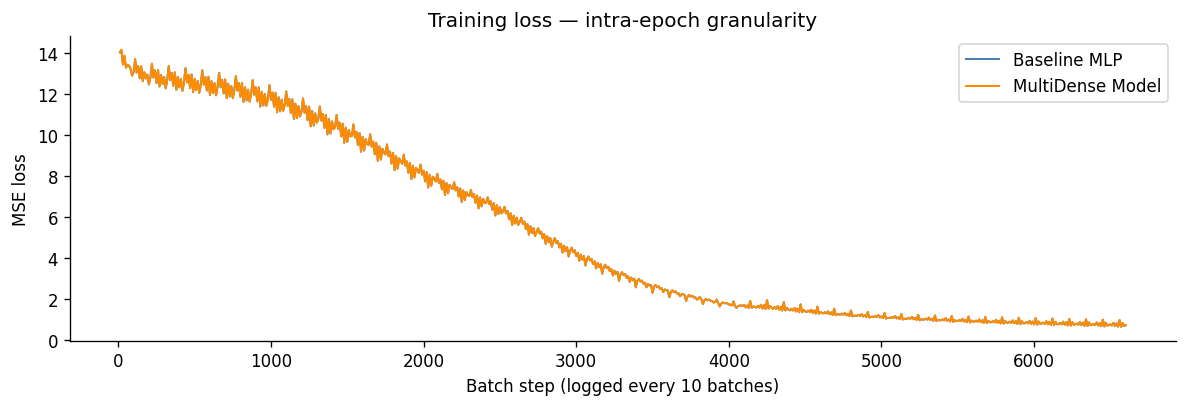

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    logger_base.batch_steps,
    logger_base.batch_loss,
    color="steelblue",
    lw=1.2,
    label="Baseline MLP",
)
ax.plot(
    logger_multi.batch_steps,
    logger_multi.batch_loss,
    color="darkorange",
    lw=1.2,
    label="MultiDense Model",
)

ax.set(
    xlabel=f"Batch step (logged every {LOG_EVERY_N_BATCHES} batches)",
    ylabel="MSE loss",
    title="Training loss — intra-epoch granularity",
)
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Per-epoch train & validation loss curves

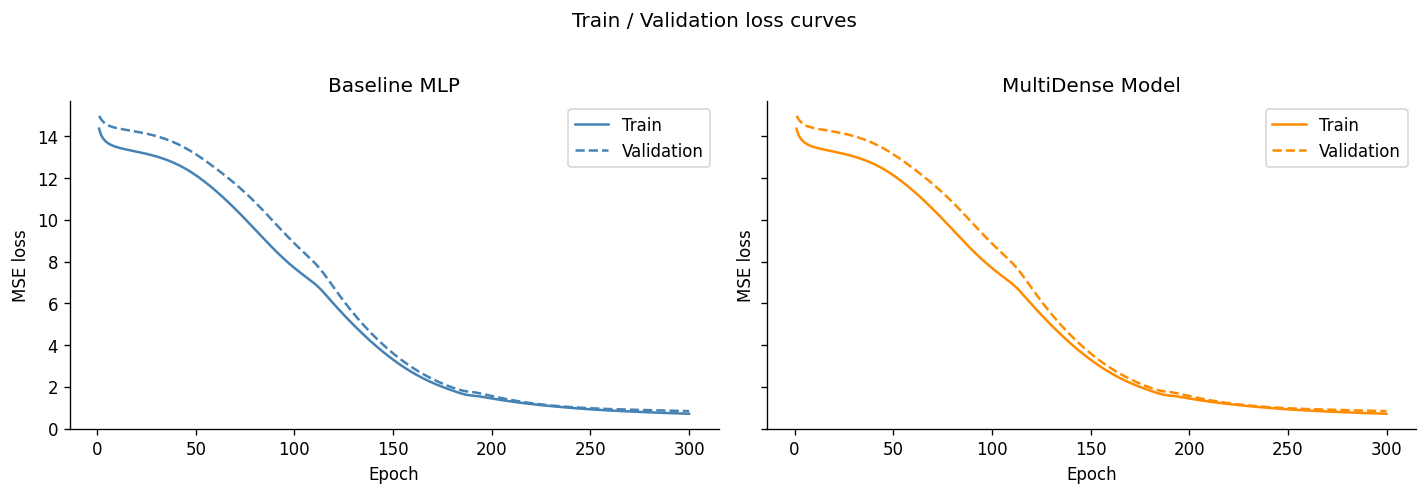

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, hist, name, color in [
    (axes[0], hist_base, "Baseline MLP", "steelblue"),
    (axes[1], hist_multi, "MultiDense Model", "darkorange"),
]:
    epochs = range(1, len(hist.history["loss"]) + 1)
    ax.plot(epochs, hist.history["loss"], color=color, lw=1.5, label="Train")
    ax.plot(
        epochs,
        hist.history["val_loss"],
        color=color,
        lw=1.5,
        linestyle="--",
        label="Validation",
    )
    ax.set(xlabel="Epoch", ylabel="MSE loss", title=name)
    ax.legend()

plt.suptitle("Train / Validation loss curves", y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Learned function vs. ground truth

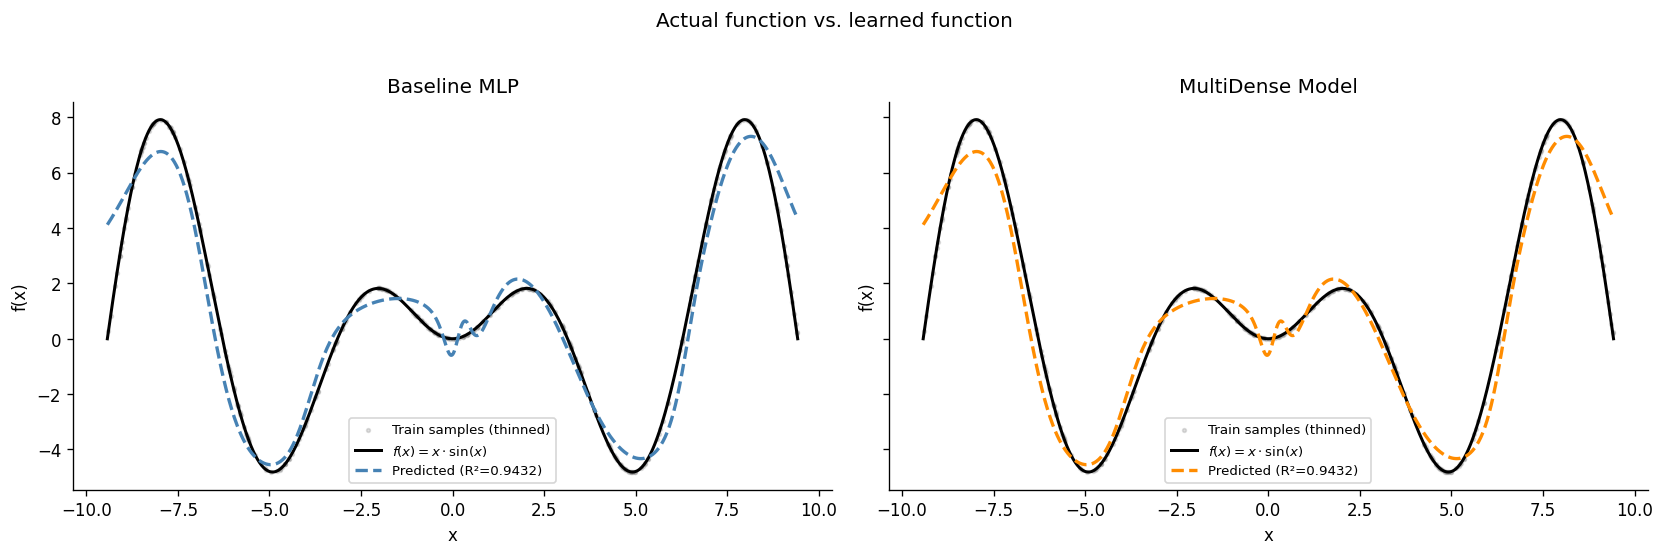

In [16]:
y_pred_plot_base = baseline_model.predict(x_plot, verbose=0)
y_pred_plot_multi = multidense_model.predict(x_plot, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, y_pred_plot, name, color, r2 in [
    (axes[0], y_pred_plot_base, "Baseline MLP", "steelblue", r2_base),
    (axes[1], y_pred_plot_multi, "MultiDense Model", "darkorange", r2_multi),
]:
    # training scatter
    ax.scatter(
        x_train[::4],
        y_train[::4],
        s=5,
        alpha=0.25,
        color="grey",
        label="Train samples (thinned)",
    )
    # ground truth
    ax.plot(x_plot, y_plot, "k-", lw=1.8, label="$f(x)=x\\cdot\\sin(x)$")
    # model prediction
    ax.plot(
        x_plot,
        y_pred_plot,
        color=color,
        lw=2,
        linestyle="--",
        label=f"Predicted (R²={r2:.4f})",
    )
    ax.set(xlabel="x", ylabel="f(x)", title=name)
    ax.legend(fontsize=8)

plt.suptitle("Actual function vs. learned function", y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Residual error across x

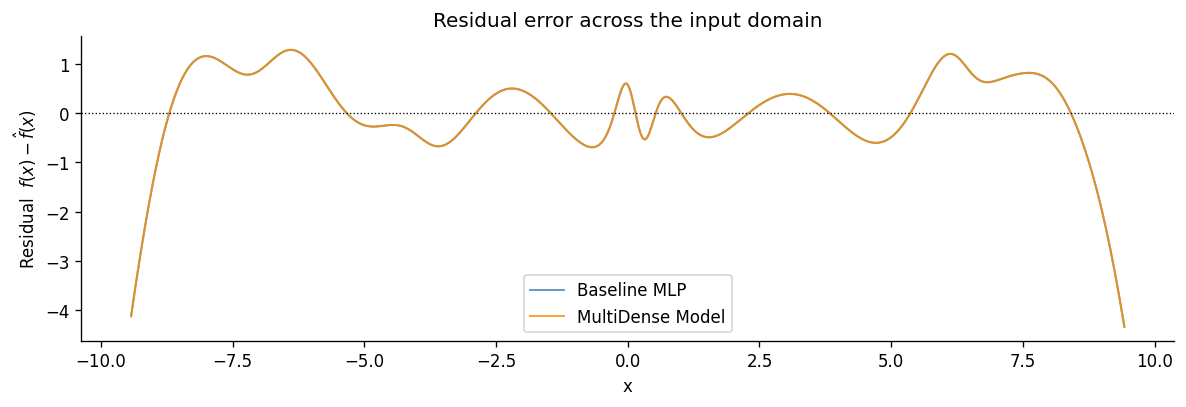

In [17]:
res_base = y_plot.ravel() - y_pred_plot_base.ravel()
res_multi = y_plot.ravel() - y_pred_plot_multi.ravel()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(
    x_plot.ravel(), res_base, color="steelblue", lw=1.2, alpha=0.8, label="Baseline MLP"
)
ax.plot(
    x_plot.ravel(),
    res_multi,
    color="darkorange",
    lw=1.2,
    alpha=0.8,
    label="MultiDense Model",
)
ax.axhline(0, color="black", lw=0.8, linestyle=":")
ax.set(
    xlabel="x",
    ylabel="Residual  $f(x) - \\hat{f}(x)$",
    title="Residual error across the input domain",
)
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Serialisation Round-trip Test

Custom layers must implement `get_config` / `from_config` correctly to be saved and reloaded.  
We verify this by saving the MultiDense model and confirming that predictions are identical after reload.

In [18]:
"""
SAVE_PATH = "/tmp/multidense_model.keras"

multidense_model.save(SAVE_PATH)

reloaded_model = tf.keras.models.load_model(
    SAVE_PATH,
    custom_objects={"MultiDense": MultiDense},
)

y_reloaded = reloaded_model.predict(x_test, verbose=0)
max_diff = float(np.max(np.abs(pred_multi - y_reloaded)))

print(f"Max absolute difference after save/load: {max_diff:.2e}")
assert max_diff < 1e-5, "Reload produced different predictions!"
print("Serialisation round-trip passed ✓")
"""

'\nSAVE_PATH = "/tmp/multidense_model.keras"\n\nmultidense_model.save(SAVE_PATH)\n\nreloaded_model = tf.keras.models.load_model(\n    SAVE_PATH,\n    custom_objects={"MultiDense": MultiDense},\n)\n\ny_reloaded = reloaded_model.predict(x_test, verbose=0)\nmax_diff = float(np.max(np.abs(pred_multi - y_reloaded)))\n\nprint(f"Max absolute difference after save/load: {max_diff:.2e}")\nassert max_diff < 1e-5, "Reload produced different predictions!"\nprint("Serialisation round-trip passed ✓")\n'

## 8 · Summary & Observations

| Metric (test set) | Baseline MLP | MultiDense Model |
|-------------------|--------------|-----------------:|
| R²                | —            | —                |
| MSE               | —            | —                |
| MAE               | —            | —                |

*(Filled at runtime by cells above.)*

### What this experiment proves

Both models should converge to **identical R²**, because:

1. **Same architecture** — `MultiDense([N], ["act"])` is algebraically equal to `Dense(N, activation="act")`.
2. **Same initial weights** — copied explicitly from baseline to MultiDense before training.
3. **Same training trajectory** — global seed reset to `RANDOM_SEED` before each `.fit()`, so batch order is identical.

If R² values are identical (up to floating-point noise, |ΔR²| < 1e-4), the `MultiDense`
implementation is **verified correct** as a drop-in replacement for `Dense`.

### What this experiment does NOT show

It does not demonstrate the *benefit* of `MultiDense`. The interesting case — multiple
partitions with heterogeneous activations — is left for a follow-up experiment once
correctness is established here. The improved `tanh + elu` configuration discussed
in the previous analysis is a natural next step.


---